### 07 - Comparaison des modeles de classification (workflow workshop)
#### HumanForYou - Attrition ML

Objectif: reproduire la partie "etude comparative" du workshop avec les donnees du projet:
- comparaison metriques,
- courbes Precision-Recall et ROC,
- temps d'entrainement/prediction,
- exports consolides.


#### 1. Imports


In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Image, display

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


#### 2. Chargement des donnees preparees


In [2]:
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
train_path = os.path.join(PROCESSED_DIR, 'attrition_train_prepared.csv')
test_path = os.path.join(PROCESSED_DIR, 'attrition_test_prepared.csv')

assert os.path.exists(train_path), f'Fichier introuvable: {train_path}'
assert os.path.exists(test_path), f'Fichier introuvable: {test_path}'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X_train = train_df.drop(columns=['Attrition']).copy()
y_train = train_df['Attrition'].astype(int).copy()
X_test = test_df.drop(columns=['Attrition']).copy()
y_test = test_df['Attrition'].astype(int).copy()

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')


X_train: (3087, 46) | X_test: (1323, 46)


#### 3. Cross-validation (comme comparaison workshop)


In [3]:
models = {
    'Perceptron': Perceptron(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=3),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for model_name, model in models.items():
    f1_scores = cross_val_score(model, X_train, y_train, scoring='f1', cv=cv, n_jobs=1)
    auc_scores = cross_val_score(model, X_train, y_train, scoring='roc_auc', cv=cv, n_jobs=1)

    cv_rows.append({
        'model': model_name,
        'f1_cv_mean': float(f1_scores.mean()),
        'f1_cv_std': float(f1_scores.std()),
        'roc_auc_cv_mean': float(auc_scores.mean()),
        'roc_auc_cv_std': float(auc_scores.std()),
    })

cv_df = pd.DataFrame(cv_rows).sort_values('f1_cv_mean', ascending=False).reset_index(drop=True)
cv_df


,model,f1_cv_mean,f1_cv_std,roc_auc_cv_mean,roc_auc_cv_std
0,RandomForest,0.890593,0.019148,0.986123,0.003493
1,SVM,0.653455,0.033047,0.930320,0.012178
2,NaiveBayes,0.426602,0.017398,0.739257,0.034673
3,LogisticRegression,0.384899,0.037181,0.812601,0.014254
4,Perceptron,0.357515,0.087543,0.710850,0.037805
5,KNN,0.343666,0.047025,0.830510,0.022091
6,DecisionTree,0.272658,0.049062,0.707891,0.016587


#### 4. Entrainement final test + timings


In [4]:
def get_positive_proba(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        raw = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-raw))
    return model.predict(X).astype(float)


comparison_rows = []
predictions_df = pd.DataFrame({'y_true': y_test})
timing_rows = []
fitted_models = {}
y_proba_by_model = {}

for model_name, model in models.items():
    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start_train

    start_pred = time.perf_counter()
    y_pred = model.predict(X_test)
    y_proba = get_positive_proba(model, X_test)
    pred_time = time.perf_counter() - start_pred

    fitted_models[model_name] = model
    y_proba_by_model[model_name] = y_proba

    predictions_df[f'y_pred_{model_name}'] = y_pred
    predictions_df[f'y_proba_{model_name}'] = y_proba

    comparison_rows.append({
        'model': model_name,
        'accuracy_test': float(accuracy_score(y_test, y_pred)),
        'precision_test': float(precision_score(y_test, y_pred, zero_division=0)),
        'recall_test': float(recall_score(y_test, y_pred, zero_division=0)),
        'f1_test': float(f1_score(y_test, y_pred, zero_division=0)),
        'roc_auc_test': float(roc_auc_score(y_test, y_proba)),
    })

    timing_rows.append({
        'model': model_name,
        'training_time_seconds': float(train_time),
        'prediction_time_seconds': float(pred_time),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('f1_test', ascending=False).reset_index(drop=True)
timing_df = pd.DataFrame(timing_rows)

comparison_df


,model,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
0,RandomForest,0.988662,1.000000,0.929577,0.963504,0.994903
1,SVM,0.913076,0.888889,0.525822,0.660767,0.935571
2,NaiveBayes,0.825397,0.451613,0.394366,0.421053,0.762594
3,Perceptron,0.812547,0.410256,0.375587,0.392157,0.734581
4,LogisticRegression,0.855631,0.622222,0.262911,0.369637,0.809237
5,KNN,0.831444,0.460938,0.276995,0.346041,0.874861
6,DecisionTree,0.851096,0.722222,0.122066,0.208835,0.728973


#### 5. Visualisations comparatives


Saved: ..\reports\figures\attrition_models_f1_test.png
Saved: ..\reports\figures\attrition_models_precision_recall.png
Saved: ..\reports\figures\attrition_models_roc_curve.png
Saved: ..\reports\figures\attrition_best_model_roc_curve.png
Saved: ..\reports\figures\attrition_models_prf_boxplot.png


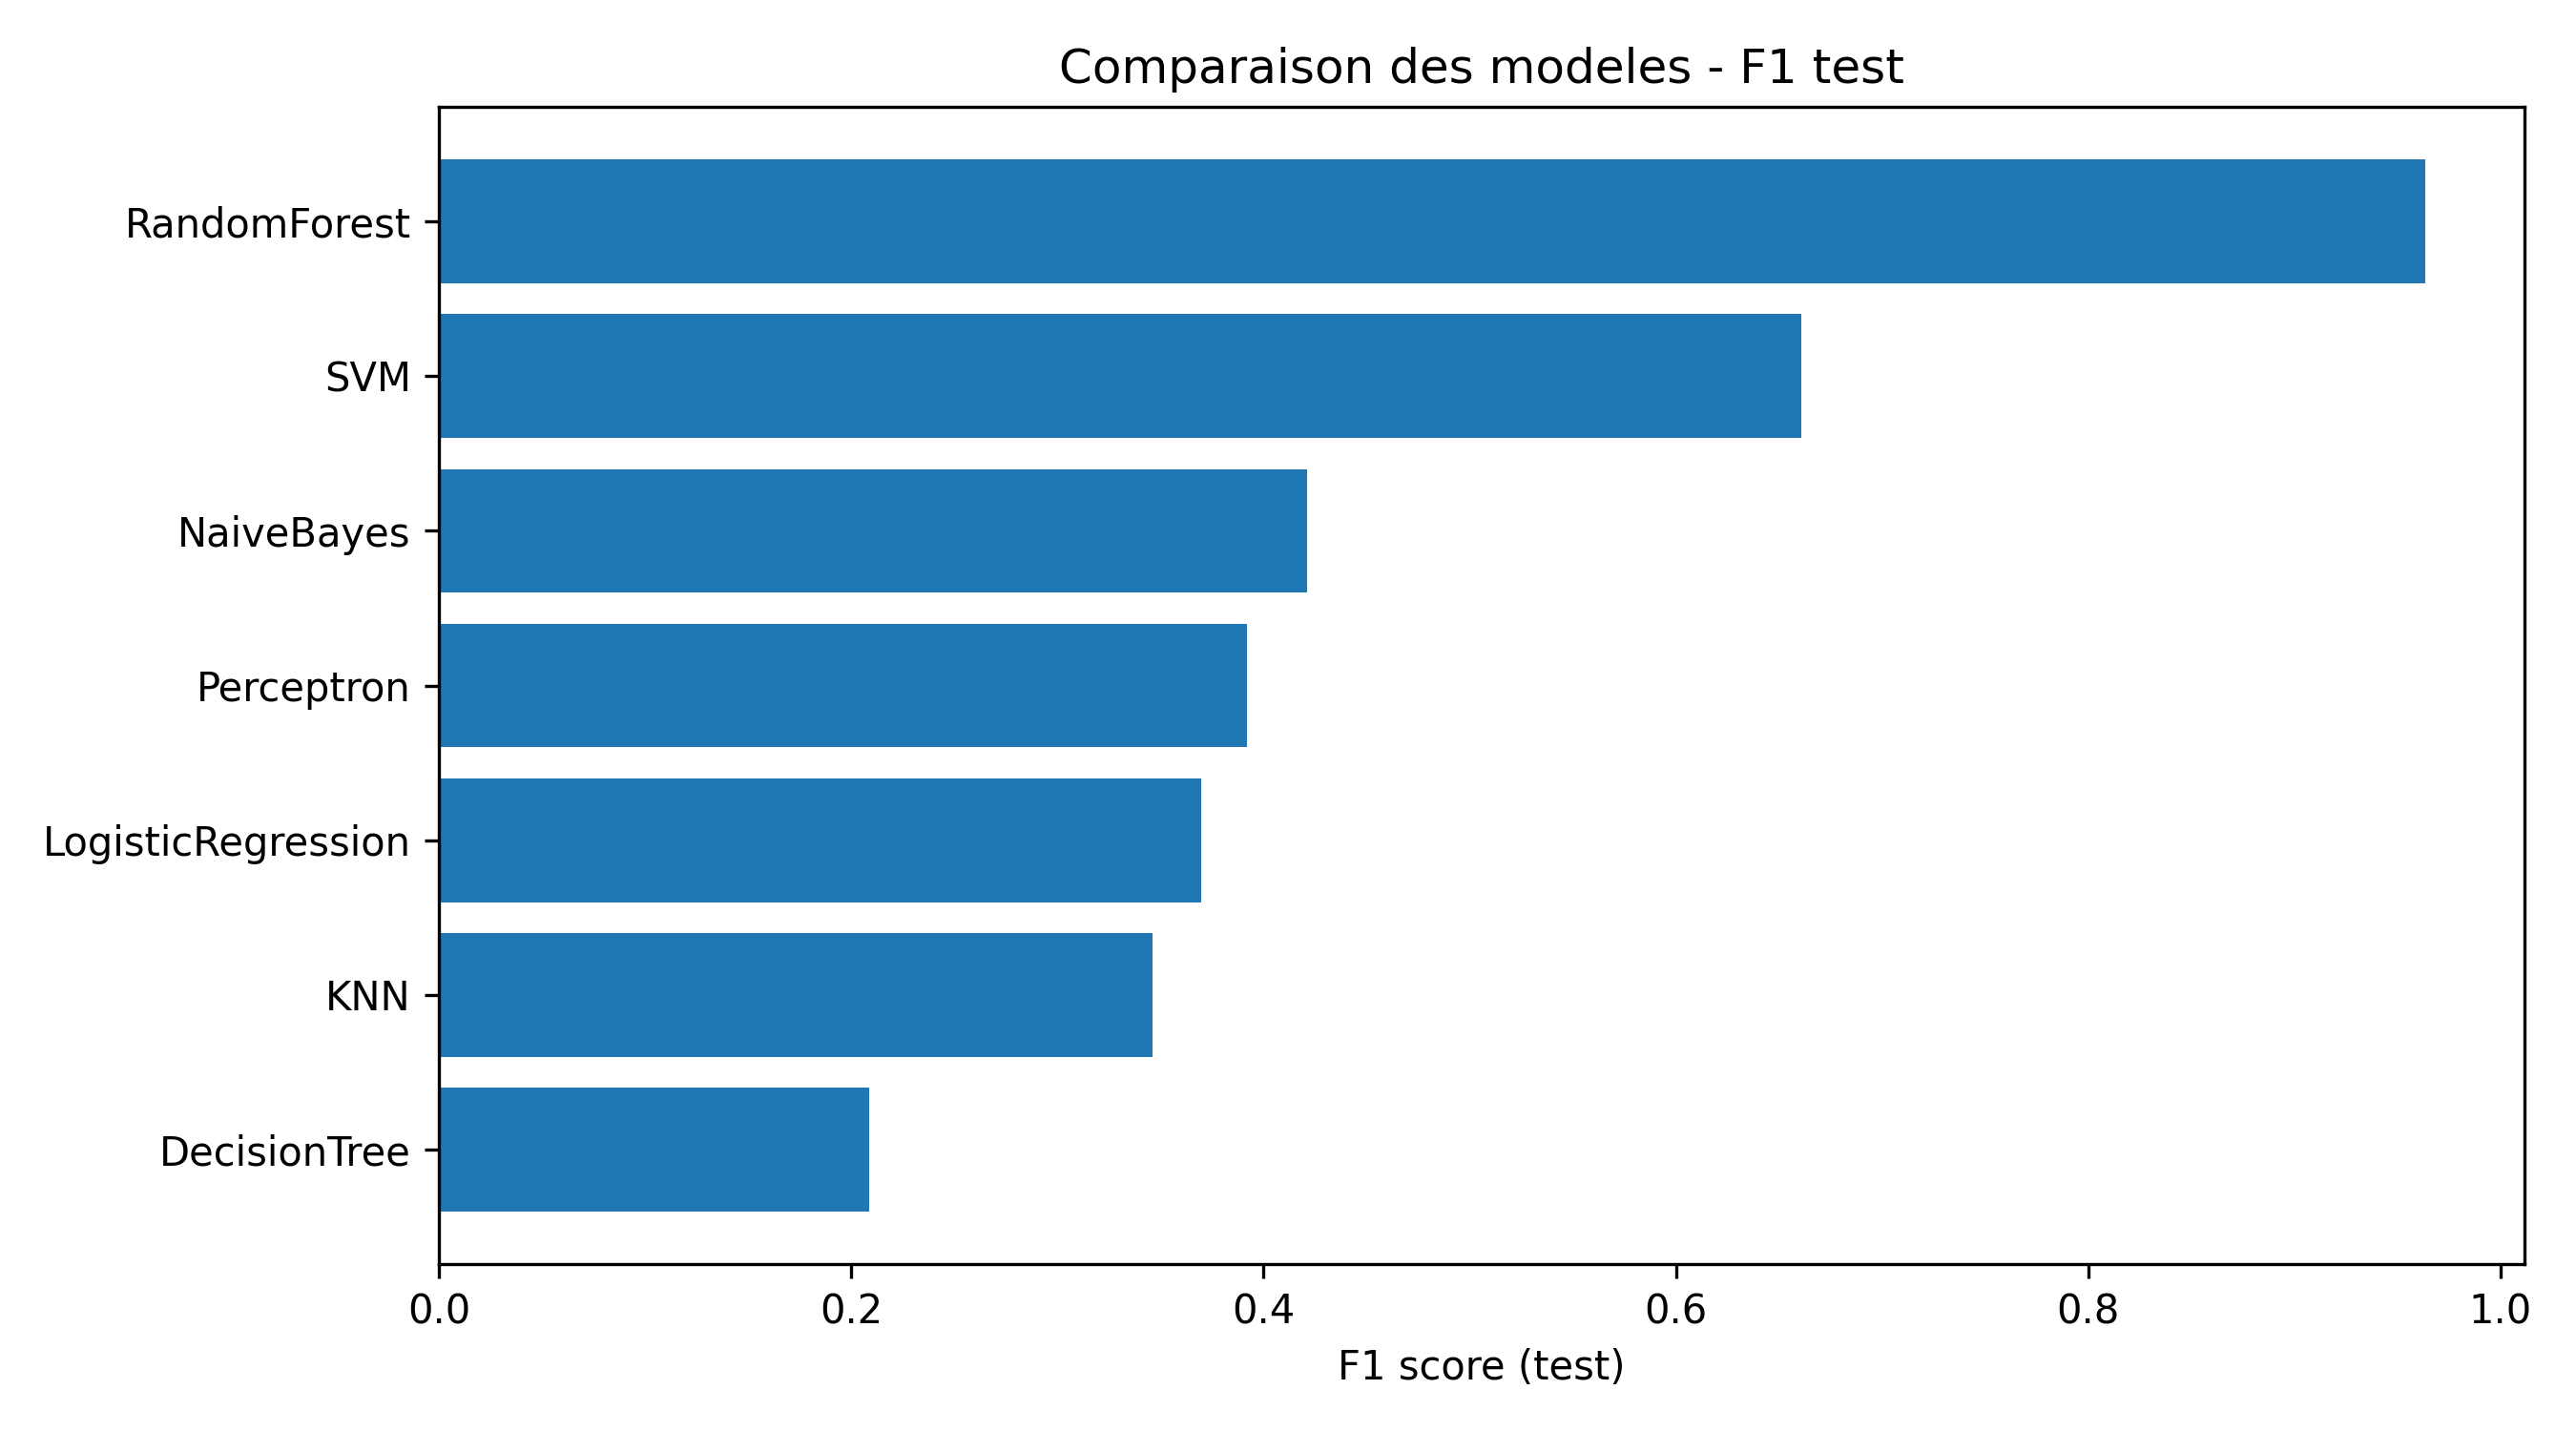

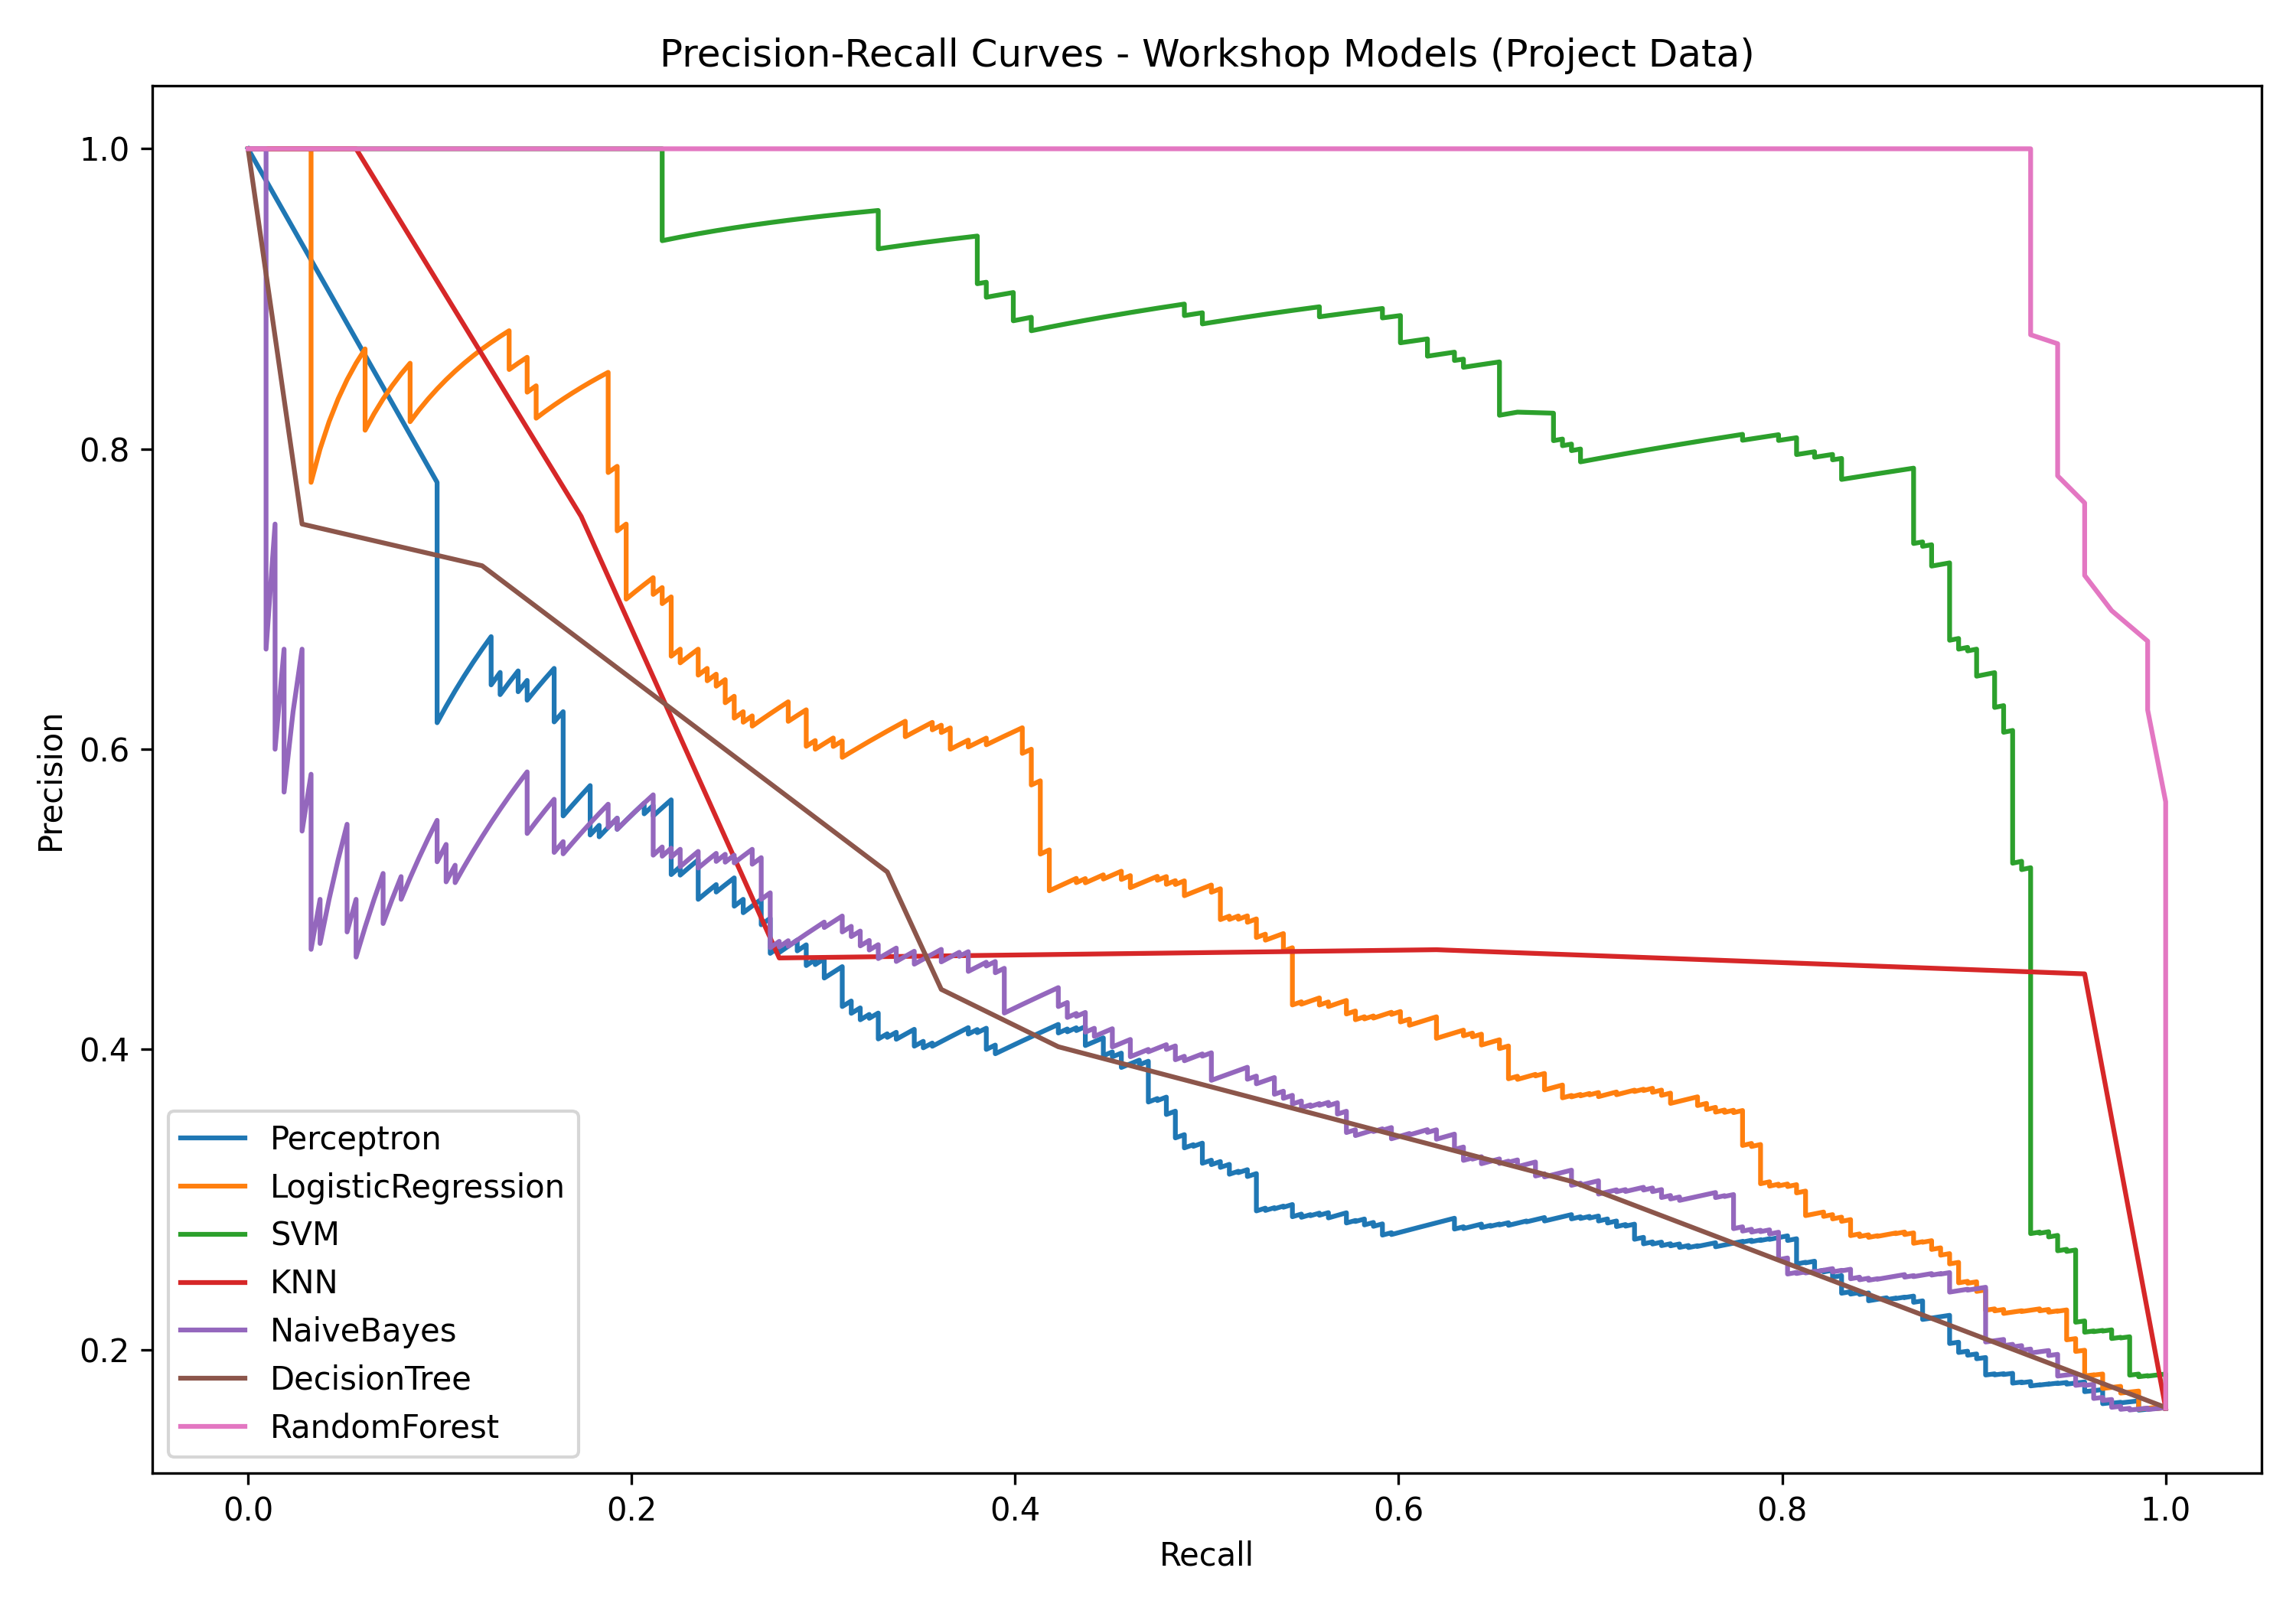

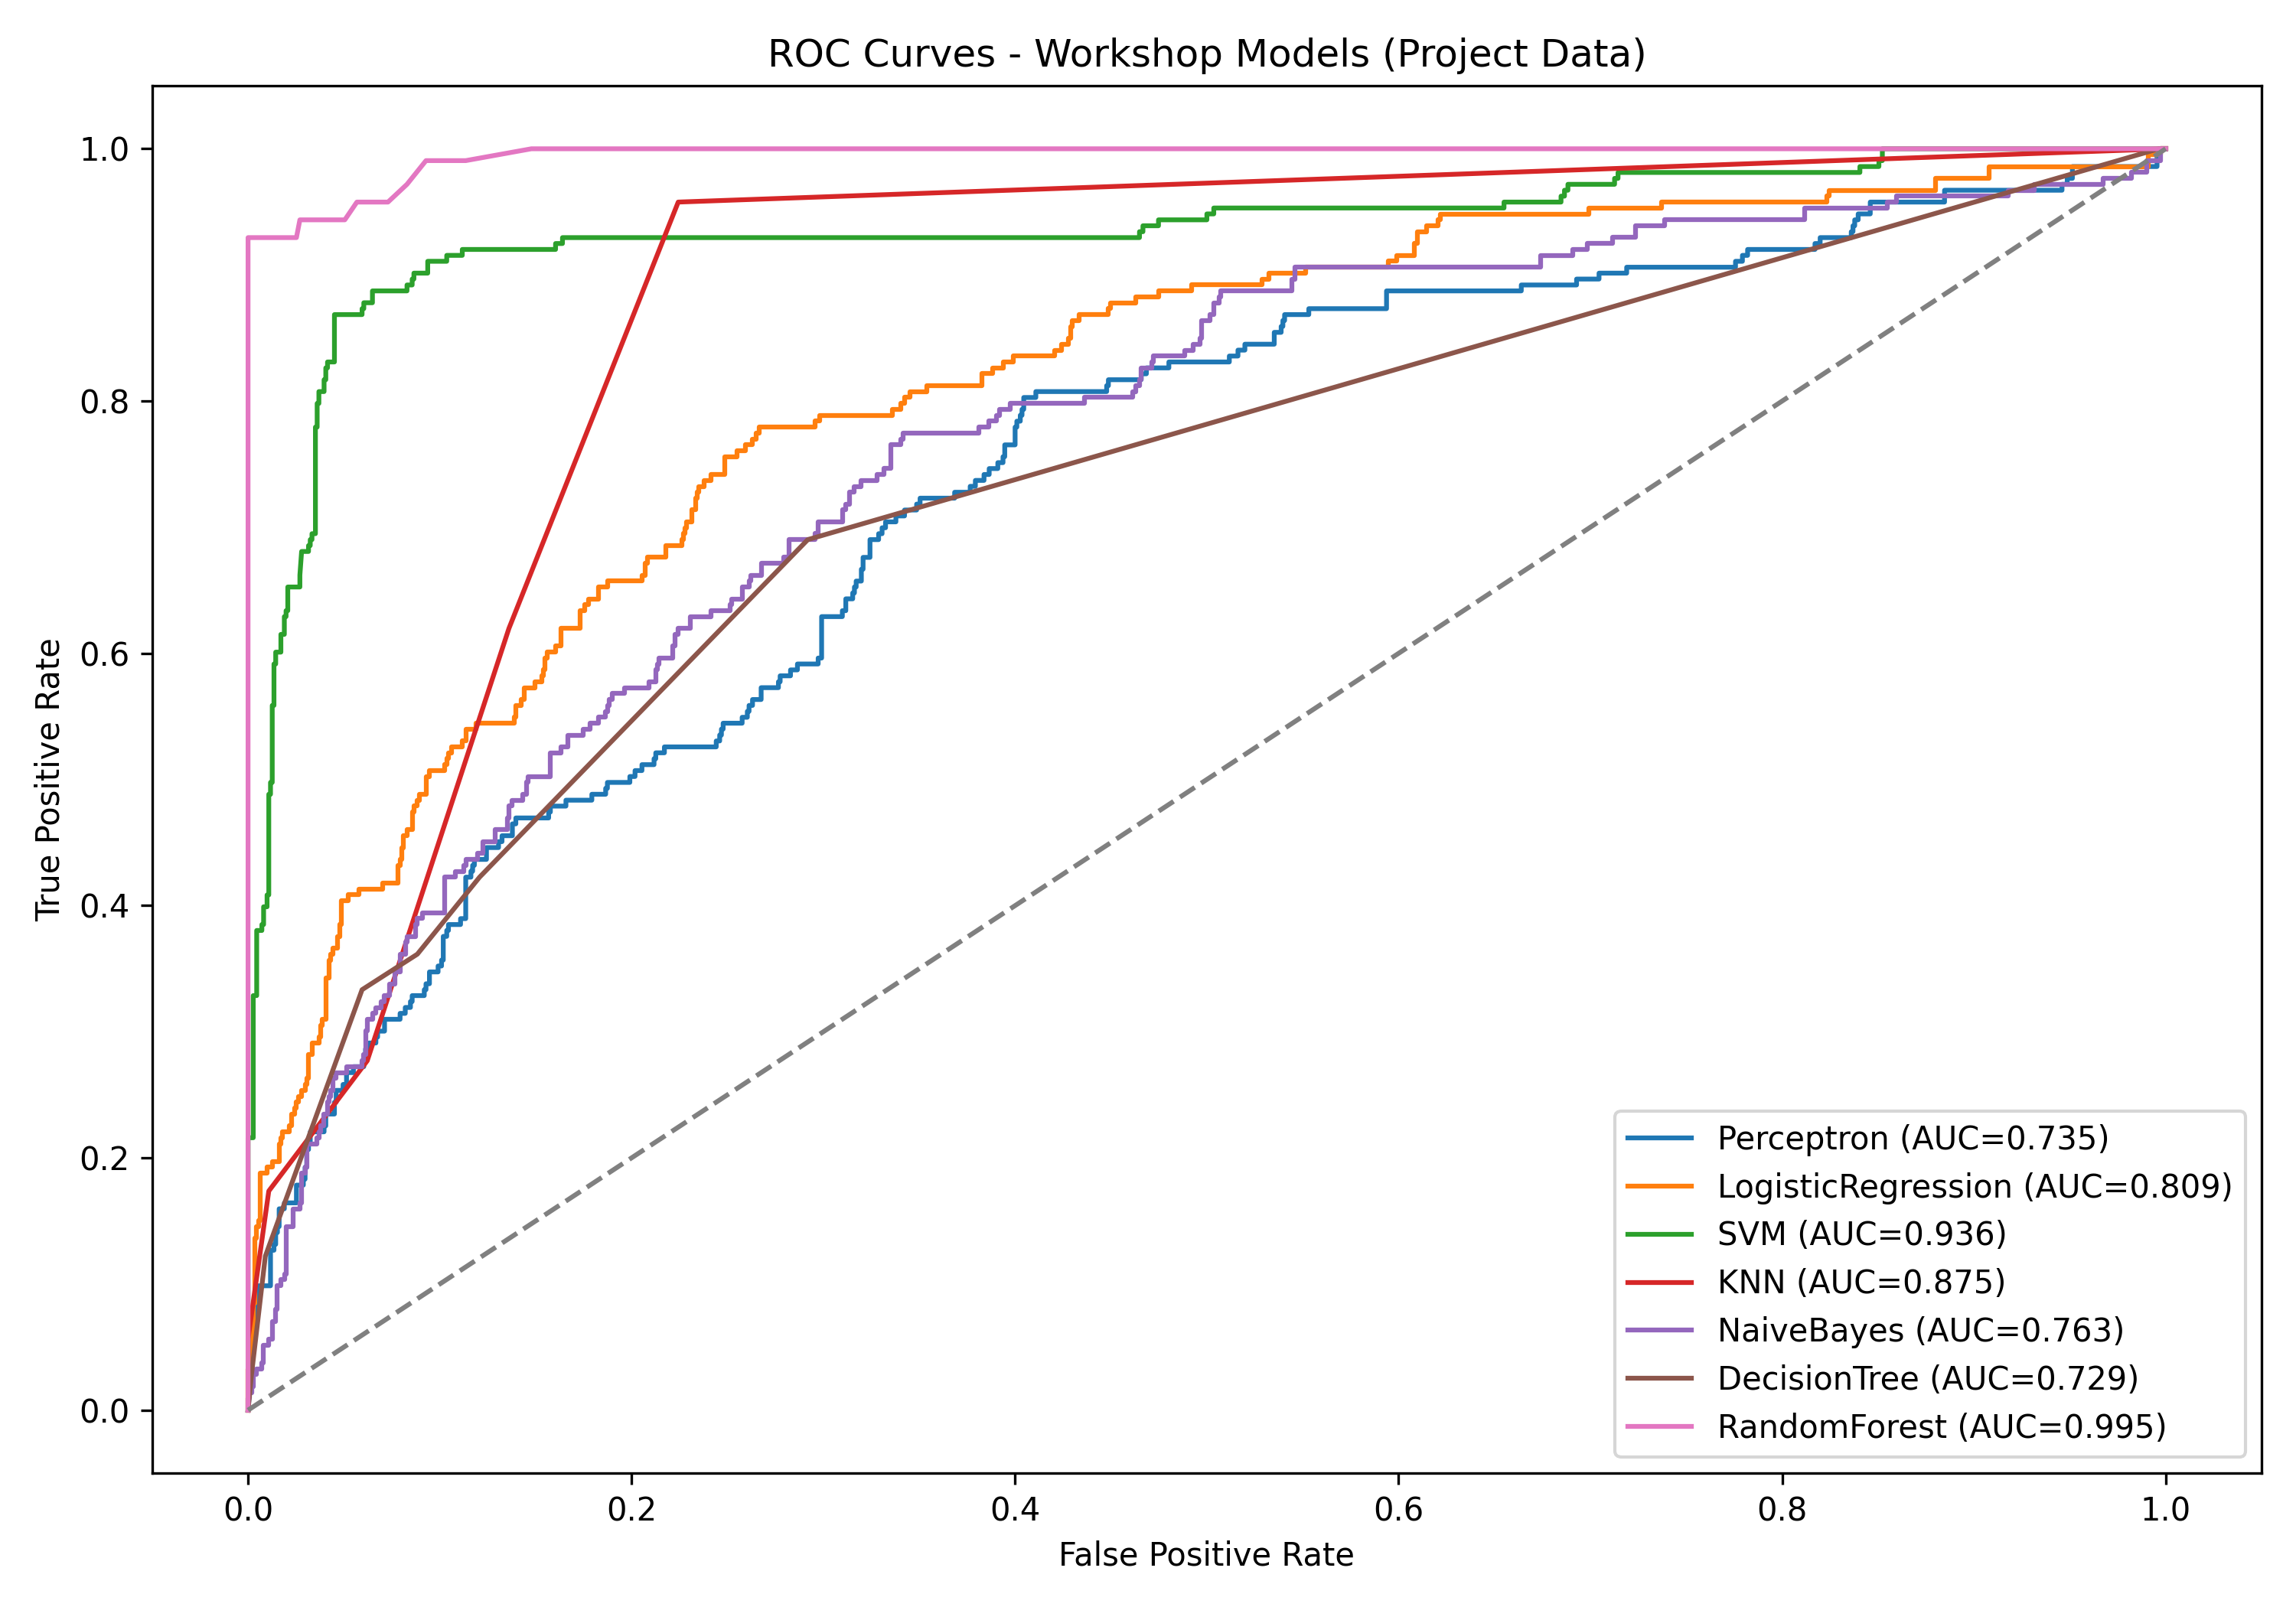

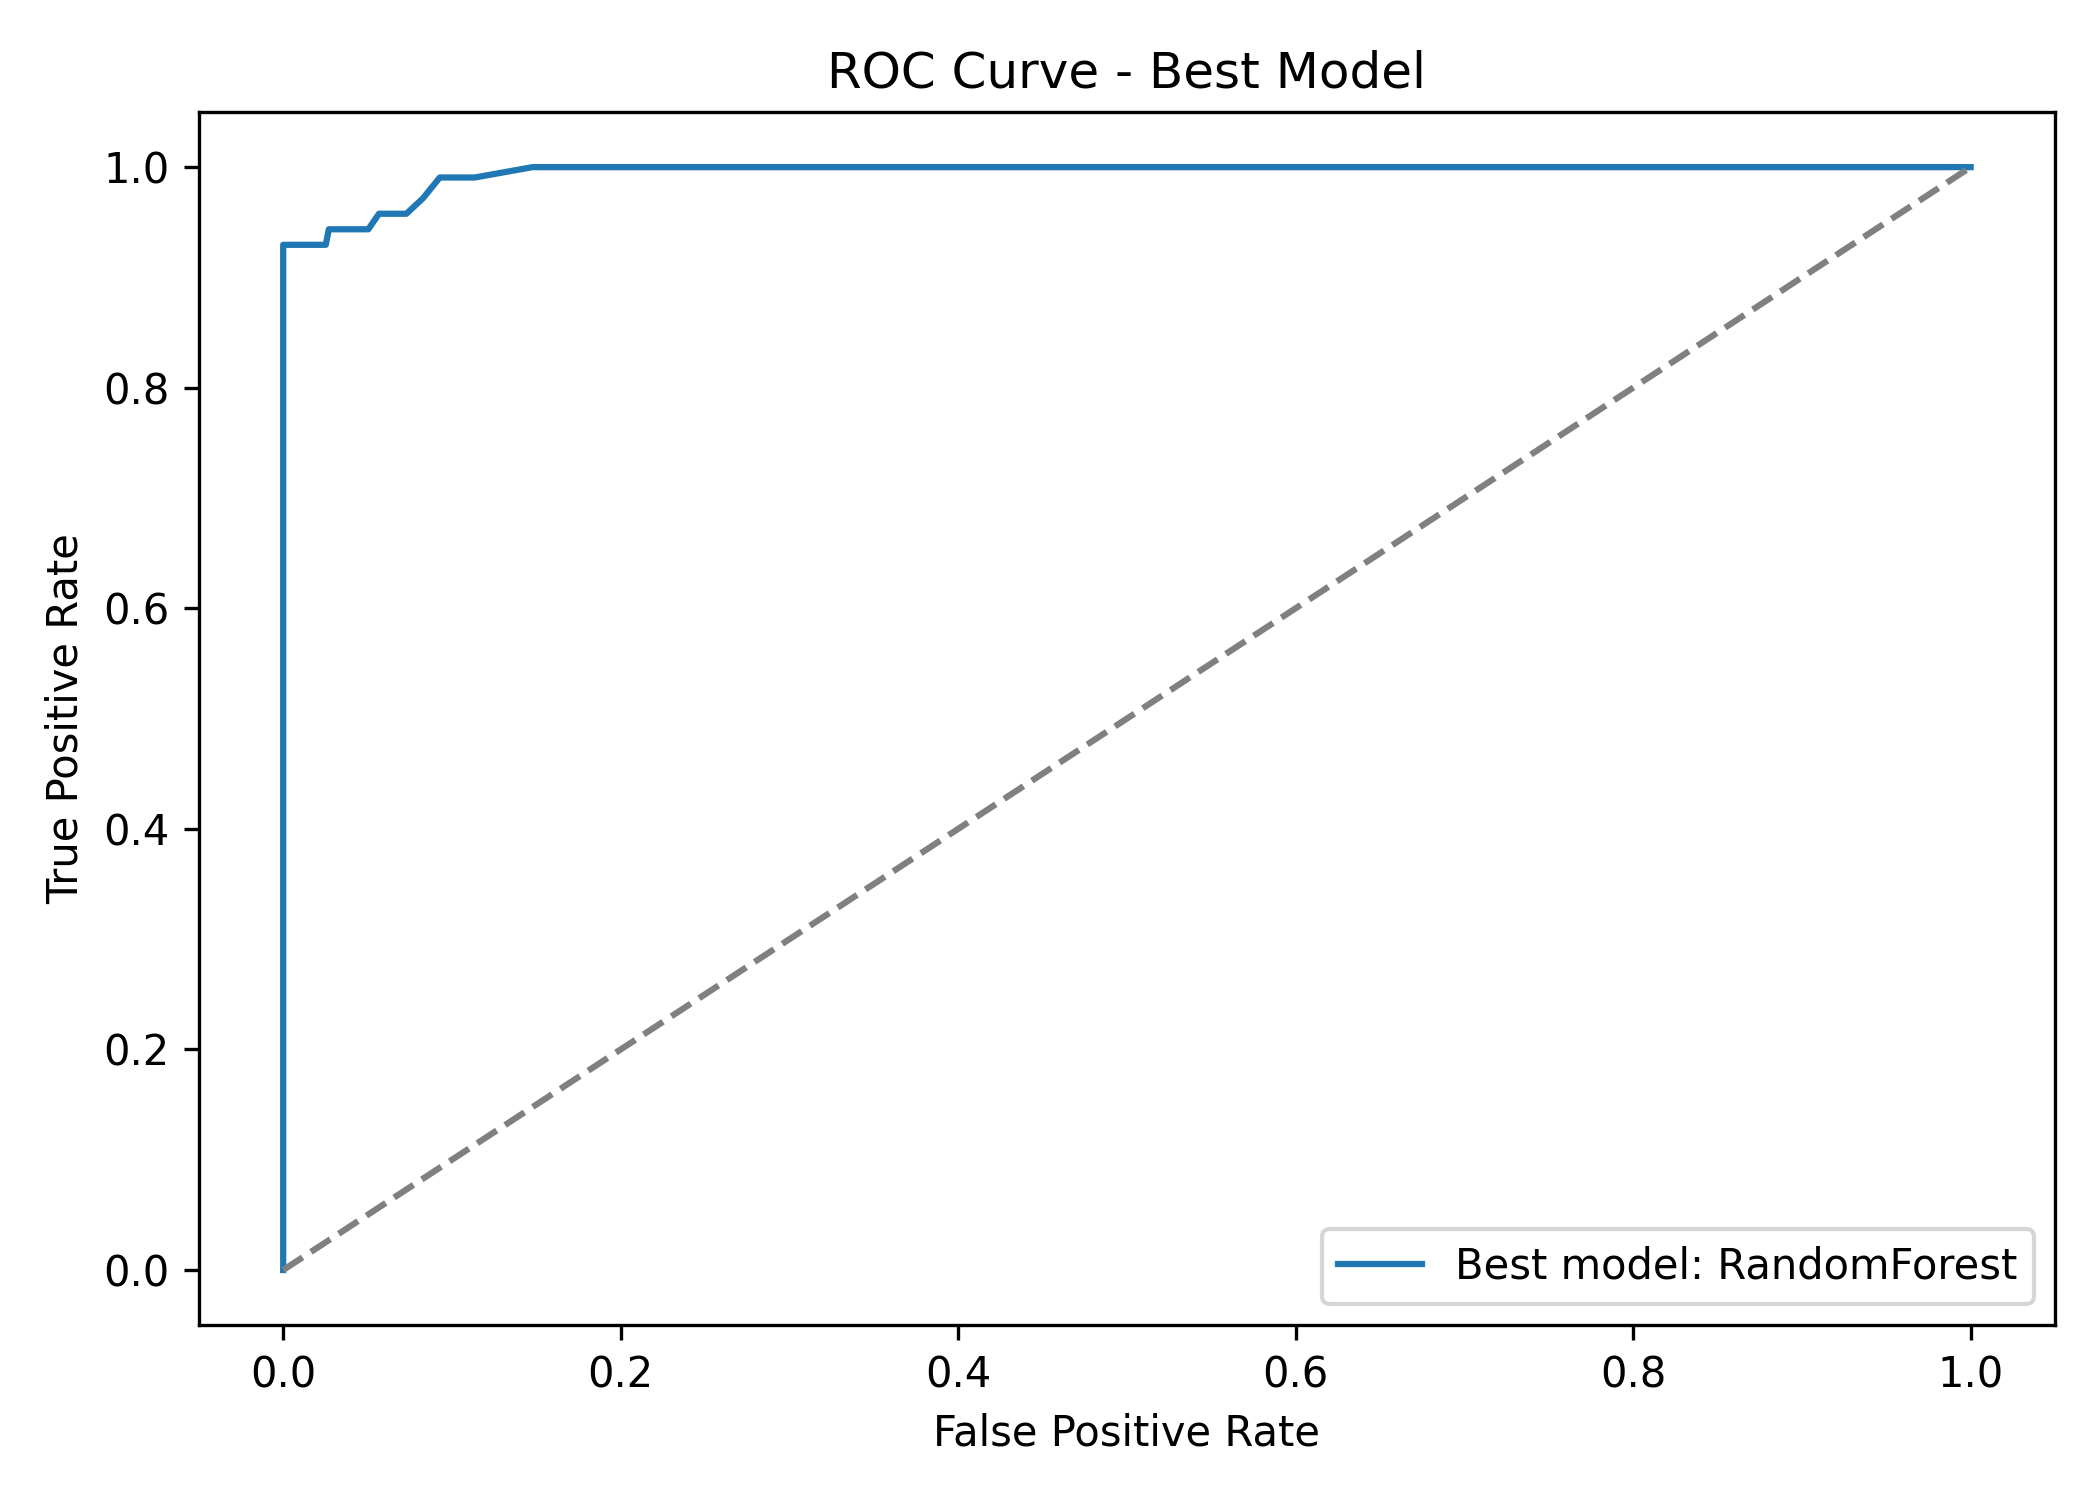

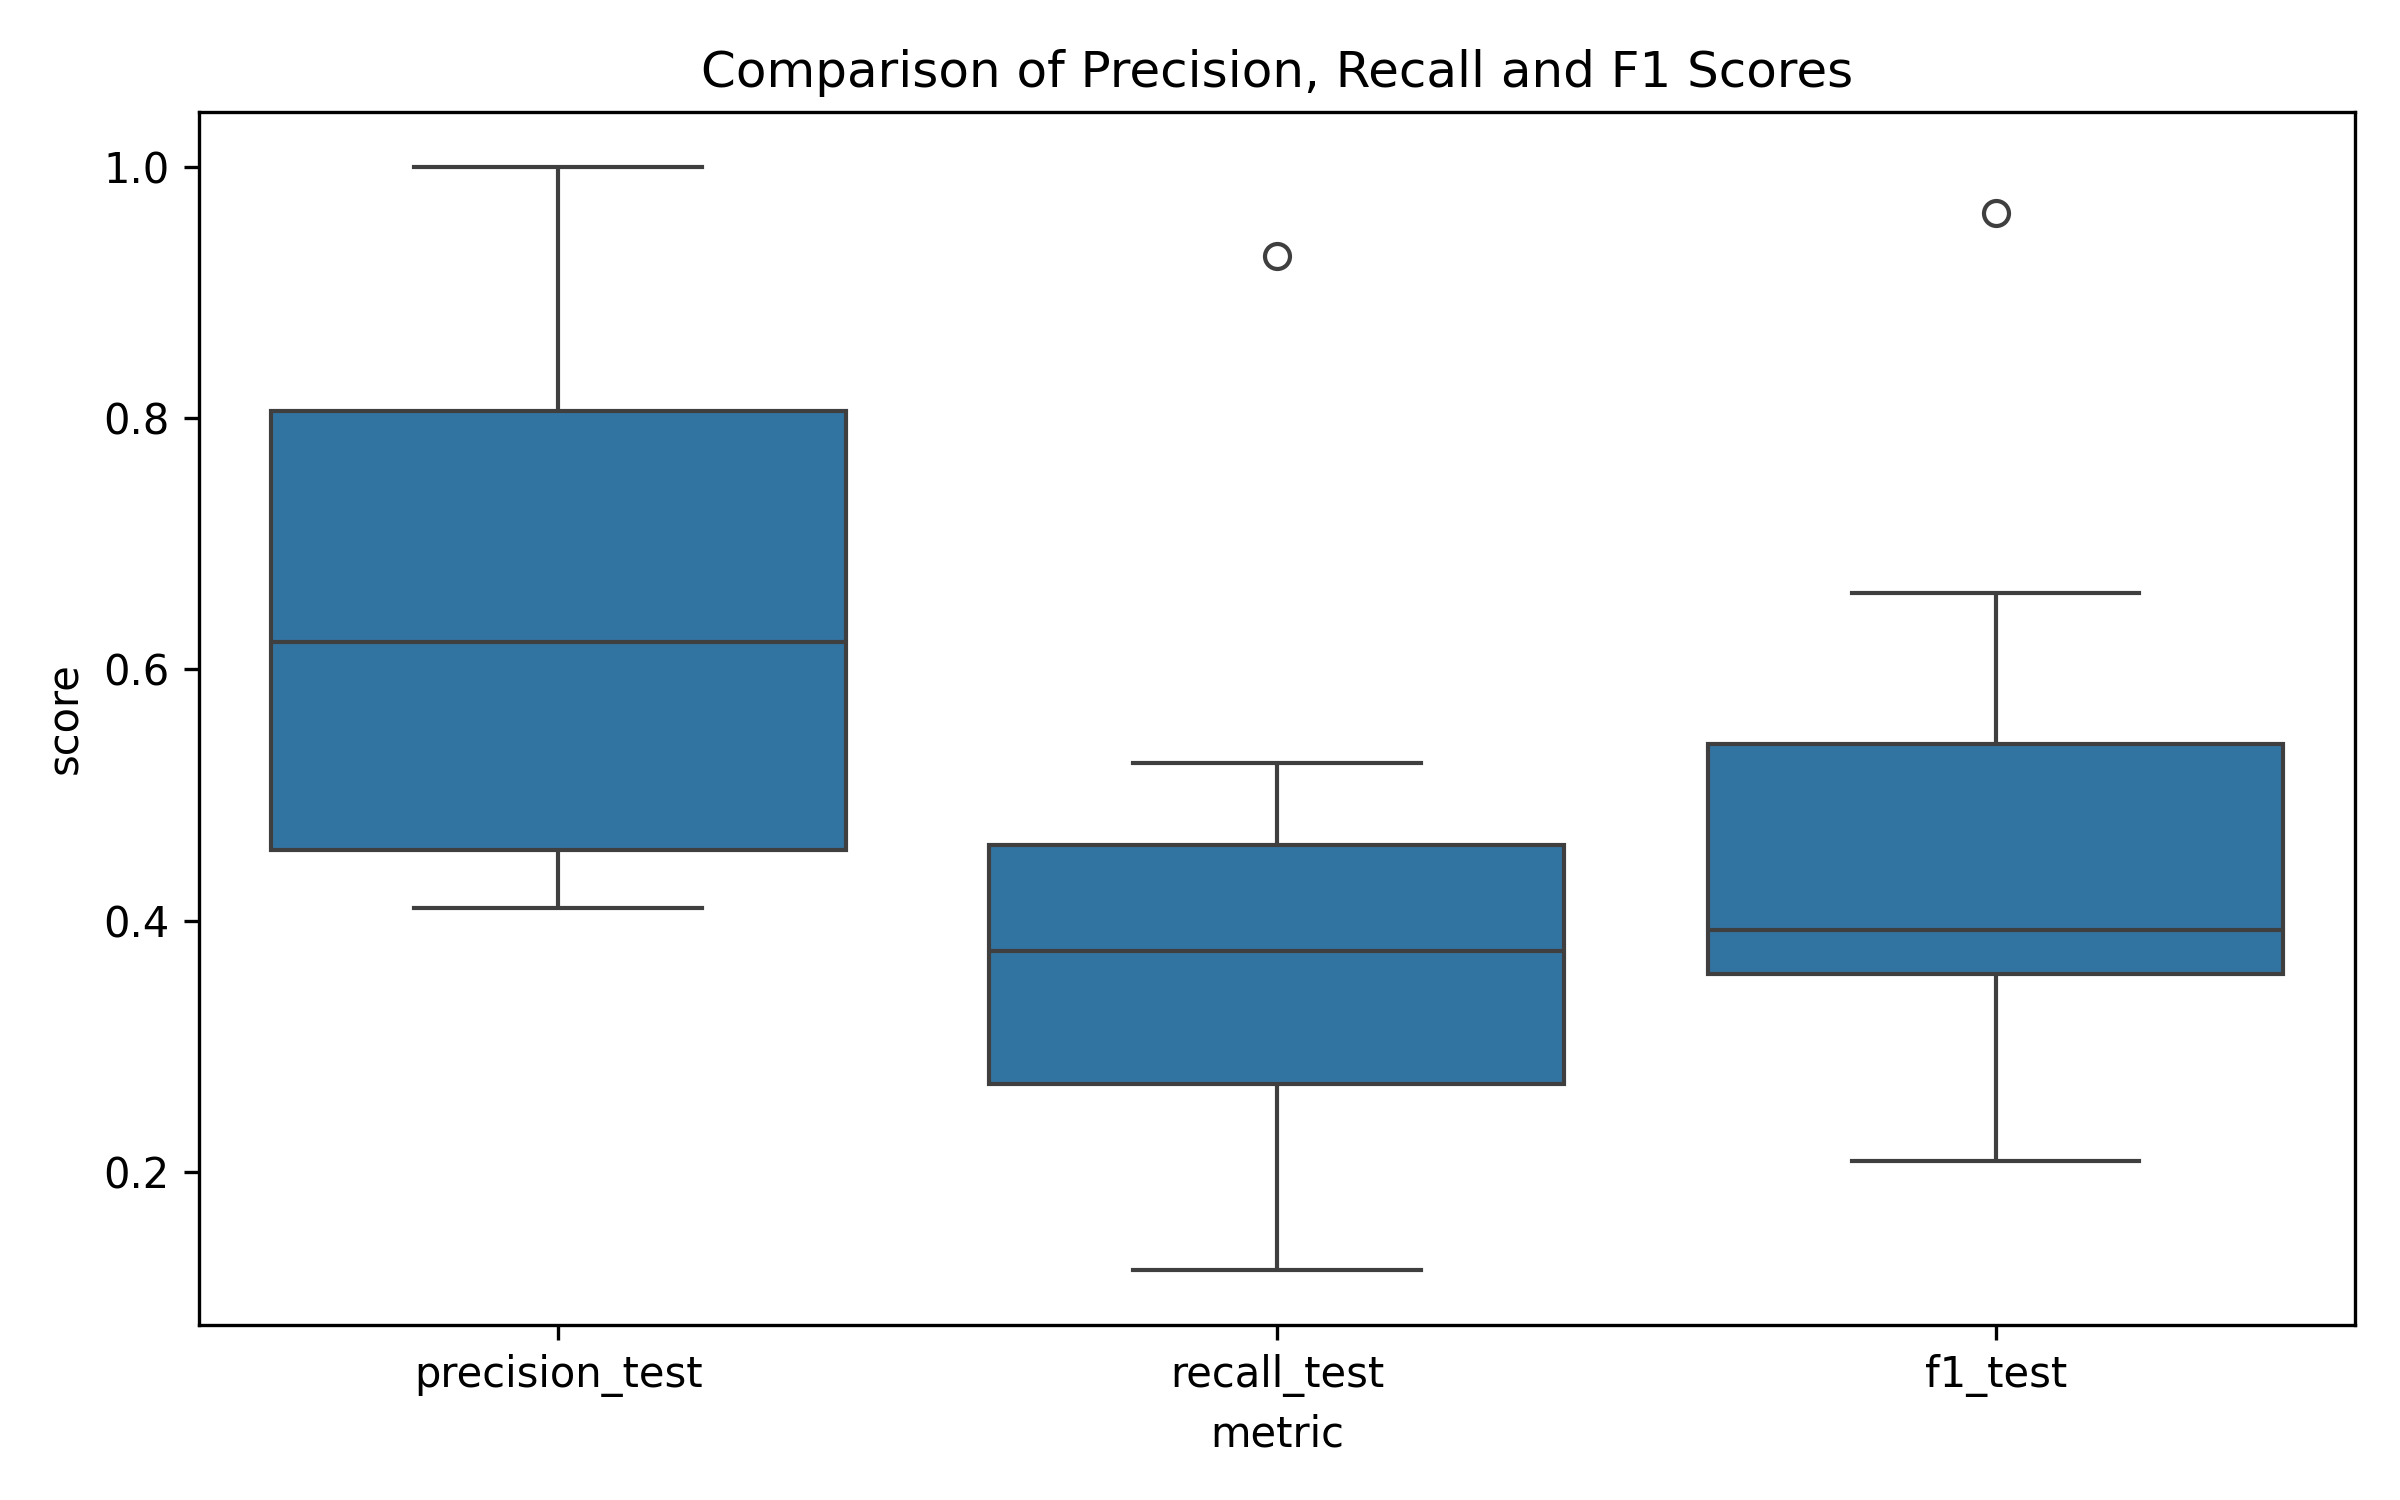

In [5]:
FIG_DIR = os.path.join('..', 'reports', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# F1 test par modele
plot_df = comparison_df.sort_values('f1_test', ascending=True)
plt.figure(figsize=(9, 5))
plt.barh(plot_df['model'], plot_df['f1_test'])
plt.xlabel('F1 score (test)')
plt.title('Comparaison des modeles - F1 test')
plt.tight_layout()
f1_fig_path = os.path.join(FIG_DIR, 'attrition_models_f1_test.png')
plt.savefig(f1_fig_path, dpi=300)
plt.close()

# Precision-Recall curve multi-modeles
plt.figure(figsize=(10, 7))
for model_name, y_proba in y_proba_by_model.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=model_name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - Workshop Models (Project Data)')
plt.legend(loc='best')
plt.tight_layout()
pr_fig_path = os.path.join(FIG_DIR, 'attrition_models_precision_recall.png')
plt.savefig(pr_fig_path, dpi=300)
plt.close()

# ROC curve multi-modeles
plt.figure(figsize=(10, 7))
for model_name, y_proba in y_proba_by_model.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Workshop Models (Project Data)')
plt.legend(loc='lower right')
plt.tight_layout()
roc_fig_path = os.path.join(FIG_DIR, 'attrition_models_roc_curve.png')
plt.savefig(roc_fig_path, dpi=300)
plt.close()

# Figure historique du meilleur modele (compatibilite)
best_model_name = comparison_df.iloc[0]['model']
best_proba = y_proba_by_model[best_model_name]
fpr_best, tpr_best, _ = roc_curve(y_test, best_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr_best, tpr_best, label=f'Best model: {best_model_name}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Model')
plt.legend(loc='lower right')
plt.tight_layout()
best_roc_fig_path = os.path.join(FIG_DIR, 'attrition_best_model_roc_curve.png')
plt.savefig(best_roc_fig_path, dpi=300)
plt.close()

# Boxplot comparaison precision/recall/f1 (style workshop)
score_long = comparison_df[['model', 'precision_test', 'recall_test', 'f1_test']].melt(
    id_vars='model',
    var_name='metric',
    value_name='score',
)

plt.figure(figsize=(8, 5))
sns.boxplot(data=score_long, x='metric', y='score')
plt.title('Comparison of Precision, Recall and F1 Scores')
plt.tight_layout()
boxplot_fig_path = os.path.join(FIG_DIR, 'attrition_models_prf_boxplot.png')
plt.savefig(boxplot_fig_path, dpi=300)
plt.close()

print(f'Saved: {f1_fig_path}')
print(f'Saved: {pr_fig_path}')
print(f'Saved: {roc_fig_path}')
print(f'Saved: {best_roc_fig_path}')
print(f'Saved: {boxplot_fig_path}')

display(Image(filename=f1_fig_path))
display(Image(filename=pr_fig_path))
display(Image(filename=roc_fig_path))
display(Image(filename=best_roc_fig_path))
display(Image(filename=boxplot_fig_path))


#### 6. Exports consolides


In [6]:
comparison_path = os.path.join(PROCESSED_DIR, 'attrition_model_comparison.csv')
predictions_path = os.path.join(PROCESSED_DIR, 'attrition_model_predictions_test.csv')
cv_path = os.path.join(PROCESSED_DIR, 'attrition_model_cv_scores.csv')
timing_path = os.path.join(PROCESSED_DIR, 'attrition_model_timing.csv')
prf_scores_path = os.path.join(PROCESSED_DIR, 'attrition_model_precision_recall_f1.csv')

comparison_df.to_csv(comparison_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
cv_df.to_csv(cv_path, index=False)
timing_df.to_csv(timing_path, index=False)

comparison_df[['model', 'precision_test', 'recall_test', 'f1_test']].to_csv(prf_scores_path, index=False)

print(f'Saved: {comparison_path}')
print(f'Saved: {predictions_path}')
print(f'Saved: {cv_path}')
print(f'Saved: {timing_path}')
print(f'Saved: {prf_scores_path}')

display(comparison_df)
display(cv_df)
display(timing_df)


Saved: ..\data\processed\attrition_model_comparison.csv
Saved: ..\data\processed\attrition_model_predictions_test.csv
Saved: ..\data\processed\attrition_model_cv_scores.csv
Saved: ..\data\processed\attrition_model_timing.csv
Saved: ..\data\processed\attrition_model_precision_recall_f1.csv


,model,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
0,RandomForest,0.988662,1.000000,0.929577,0.963504,0.994903
1,SVM,0.913076,0.888889,0.525822,0.660767,0.935571
2,NaiveBayes,0.825397,0.451613,0.394366,0.421053,0.762594
3,Perceptron,0.812547,0.410256,0.375587,0.392157,0.734581
4,LogisticRegression,0.855631,0.622222,0.262911,0.369637,0.809237
5,KNN,0.831444,0.460938,0.276995,0.346041,0.874861
6,DecisionTree,0.851096,0.722222,0.122066,0.208835,0.728973


,model,f1_cv_mean,f1_cv_std,roc_auc_cv_mean,roc_auc_cv_std
0,RandomForest,0.890593,0.019148,0.986123,0.003493
1,SVM,0.653455,0.033047,0.930320,0.012178
2,NaiveBayes,0.426602,0.017398,0.739257,0.034673
3,LogisticRegression,0.384899,0.037181,0.812601,0.014254
4,Perceptron,0.357515,0.087543,0.710850,0.037805
5,KNN,0.343666,0.047025,0.830510,0.022091
6,DecisionTree,0.272658,0.049062,0.707891,0.016587


,model,training_time_seconds,prediction_time_seconds
0,Perceptron,0.005360,0.002724
1,LogisticRegression,0.010439,0.001571
2,SVM,0.962407,0.259653
3,KNN,0.002213,0.041386
4,NaiveBayes,0.005729,0.004685
5,DecisionTree,0.017699,0.003170
6,RandomForest,0.200449,0.061962
